# Part 2 · Circuits / Digital Quantum Computing

In Part 1, quantum states were static mathematical objects that we inspected with numpy. Now we **operate** on them. The **digital** (gate-model) paradigm builds programs as **circuits** of discrete **gates** and then **executes** them on a backend, much the way a classical program is a sequence of logic-gate operations executed on a CPU.

This is the model behind the best-known quantum algorithms: Shor's factoring algorithm (the reason post-quantum cryptography is now a field), Grover's search, and the quantum-chemistry circuits of Part 4. Running those at useful sizes needs larger and cleaner machines than 2026 hardware provides. One gate-model application, however, is already in production: certified quantum random number generation, in which the physics of measurement guarantees the bits are unpredictable. Section 2.4 builds one.

By the end of this notebook you will be able to:

- assemble a **`Circuit`** from gates and understand each gate as a **unitary matrix** acting on the state;
- **run** a circuit on the **`QiliSim`** simulator and read out **sampled** vs **exact** results;
- prepare multi-qubit **entanglement** gate by gate and use it as a shared secret;
- build a provably fair **quantum dice roller**, a toy-size quantum random number generator.

### The one execution pattern

Everything you run in QiliSDK, in this notebook and for the rest of the tutorial, goes through a single call:

$$\texttt{Backend.execute(functional, readout)} \;\longrightarrow\; \texttt{Result}$$

A **Functional** says *what* to run, a **Backend** says *where*, and a **Readout** says *what to measure*. A claim we will demonstrate by Part 6: **the same functional and readout run on any backend, CPU, GPU, or QPU (quantum processing unit, the actual quantum chip), by changing one line.**

In [1]:
# ▶ Run me first. No-op if QiliSDK is already installed; installs it on a fresh env (e.g. Google Colab).
try:
    import qilisdk
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "qilisdk[openqasm,qir]==0.2.1", "matplotlib", "numpy"], check=True)
    import qilisdk  # Colab: if this still fails, Runtime > Restart session, then rerun
print("QiliSDK", qilisdk.__version__)

QiliSDK 0.2.1


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 2.1 · Gates & circuits

Quantum **gates** are how we *change* a state. Mathematically, a gate on $n$ qubits is a $2^n \times 2^n$ **unitary matrix** $U$. Unitary means $U^\dagger U = I$, where the **dagger** $\dagger$ is the conjugate transpose (in numpy: `U.conj().T`). Unitarity has two consequences:

- gates are **reversible**: the inverse of $U$ is simply $U^\dagger$, so any measurement-free circuit can be run backwards;
- gates **preserve the norm** of the state, so the Born-rule probabilities from Part 1 keep summing to 1.

Applying a gate is plain matrix-vector multiplication, the same operation you did with numpy in Part 1: $|\psi'\rangle = U\,|\psi\rangle$.

Four gates you will use constantly:

- **Hadamard** $H = \tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ turns certainty into a 50/50 superposition: $H|0\rangle = \tfrac{1}{\sqrt2}\,(|0\rangle + |1\rangle)$, the state Part 1 called $|+\rangle$. It is the gate that creates superposition from a definite state.
- **Pauli-$X$** $= \begin{pmatrix}0&1\\1&0\end{pmatrix}$ is the quantum NOT: $X|0\rangle = |1\rangle$ and $X|1\rangle = |0\rangle$. (Together with $Y$ and $Z$ these are the Pauli matrices from Part 1.)
- **Rotations** $R_X(\theta)$, $R_Y(\theta)$, $R_Z(\phi)$ are *continuously tunable* gates: the angle is a plain Python float, a knob you can turn. Adjusting such an angle until the output improves is exactly what the variational algorithms of Part 4 do. (For the curious: $R_X(\theta) = e^{-i\theta X/2}$ is a **matrix exponential**, like `scipy.linalg.expm`, the continuous analog of applying one big gate in many small slices.)
- **CNOT** (controlled-NOT) is a *two-qubit* gate: it flips the **target** qubit if and only if the **control** qubit is $|1\rangle$. In programmer terms it is `target ^= control` (an XOR), except that it also works when the control is in superposition.

CNOT's truth table, writing the control as the first digit and the target as the second:

| in (control, target) | out | why |
|---|---|---|
| $\lvert 00\rangle$ | $\lvert 00\rangle$ | control is 0: do nothing |
| $\lvert 01\rangle$ | $\lvert 01\rangle$ | control is 0: do nothing |
| $\lvert 10\rangle$ | $\lvert 11\rangle$ | control is 1: flip the target |
| $\lvert 11\rangle$ | $\lvert 10\rangle$ | control is 1: flip the target |

Applied to a control that is in superposition, CNOT is the standard way to **create entanglement**, as you will see shortly.

A **`Circuit`** is an ordered sequence of gates over qubits indexed $0, 1, 2, \dots$. You build it by calling `.add(...)`. Running a measurement-free circuit means multiplying its gate matrices into the initial state $|0\cdots0\rangle$. One subtlety about ordering: applying gate $A$ *then* gate $B$ to a state computes $B\,A\,|\psi\rangle$. The first gate you apply ends up rightmost, next to the state, exactly like function composition $f(g(x))$: read it inside out. QiliSDK handles that bookkeeping; you just `.add` gates in the order they happen in time.

The simplest possible circuit is one qubit, one $X$, one measurement. On the starting state $|0\rangle$ it behaves exactly like a classical NOT on a `0` bit, so we know precisely what to expect when we execute it in section 2.2: the outcome `'1'`, on every shot.

In [3]:
from qilisdk.digital import Circuit, H, X, Y, Z, S, T, CNOT, M, RX

quantum_not = Circuit(1)         # a register of 1 qubit, starting in |0>
quantum_not.add(X(0))            # quantum NOT on qubit 0: |0> -> |1>
quantum_not.add(M(0))            # measure qubit 0
print(quantum_not)

Circuit(nqubits=1, gates=[X(0), M(0)])


### Gates up close: the matrix behind each one

We said a gate *is* a unitary matrix, and QiliSDK doesn't hide it: every gate object carries its matrix on **`.matrix`**, the exact numbers your circuit multiplies into the state. Here are the six single-qubit workhorses. You already know $H$ and $X$; the rest round out the toolkit:

- **$Y = \begin{pmatrix}0 & -i\\ i & 0\end{pmatrix}$**, the third Pauli, is a bit flip and a phase flip rolled into one.
- **$Z = \begin{pmatrix}1 & 0\\ 0 & -1\end{pmatrix}$** is the **phase flip**: it leaves $|0\rangle$ alone and multiplies $|1\rangle$ by $-1$.
- **$S$** and **$T$** are smaller phase rotations, a quarter-turn and an eighth-turn about the $Z$ axis, the building blocks a circuit stacks up to reach any angle it needs.

In [4]:
# Every gate object carries its own matrix on `.matrix`.
for name, gate in [("H", H(0)), ("X", X(0)), ("Y", Y(0)),
                   ("Z", Z(0)), ("S", S(0)), ("T", T(0))]:
    print(f"{name} =\n{np.round(gate.matrix, 3)}\n")

H =
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]

X =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Y =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

S =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T =
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]



### What the gates do to your four states

Matrices are exact but hard to read at a glance. A more readable view is a **truth table**: take the four reference states from Part 1 and ask what each gate turns them into. Three gates tell the whole story of single-qubit logic:

| gate | $\lvert 0\rangle$ | $\lvert 1\rangle$ | $\lvert +\rangle$ | $\lvert -\rangle$ | in one phrase |
|---|---|---|---|---|---|
| $X$ | $\lvert 1\rangle$ | $\lvert 0\rangle$ | $\lvert +\rangle$ | $-\lvert -\rangle$ | **bit flip**: swaps the poles, fixes the equator |
| $Z$ | $\lvert 0\rangle$ | $-\lvert 1\rangle$ | $\lvert -\rangle$ | $\lvert +\rangle$ | **phase flip**: fixes the poles, swaps the equator |
| $H$ | $\lvert +\rangle$ | $\lvert -\rangle$ | $\lvert 0\rangle$ | $\lvert 1\rangle$ | **basis swap**: turns poles into equator and back |

Two points to notice. First, $X$ and $Z$ are mirror images: $X$ swaps $|0\rangle\leftrightarrow|1\rangle$ but leaves $|+\rangle,|-\rangle$ fixed (up to a sign), while $Z$ does exactly the reverse. That is why $X$ is the **bit** flip and $Z$ the **phase** flip. Second, $H$ is the bridge between the two bases: it carries the $Z$ basis to the $X$ basis and back, which is precisely why it turns a definite $|0\rangle$ into the fifty-fifty $|+\rangle$.

Note the minus signs below ($X|-\rangle = -|-\rangle$, $Z|1\rangle = -|1\rangle$). They are **relative phases**, and they are exactly the information a computational-basis measurement throws away, which is why the probabilities alone can never reveal them.

In [5]:
from qilisdk.core import QTensor, ket           # states live in Core, gates in `digital`

refs = {
    "|0>": ket(0),
    "|1>": ket(1),
    "|+>": QTensor.uniform(1),
    "|->": (ket(0) - ket(1)).normalized(),
}

for gname, gate in [("X", X(0)), ("Z", Z(0)), ("H", H(0))]:
    U = QTensor(gate.matrix)                    # wrap the gate's matrix as an operator
    print(f"--- {gname} ---")
    for sname, s in refs.items():
        out = np.round((U @ s).dense().ravel(), 3)
        print(f"  {gname} {sname:<4} -> {out}")

--- X ---
  X |0>  -> [0.+0.j 1.+0.j]
  X |1>  -> [1.+0.j 0.+0.j]
  X |+>  -> [0.707+0.j 0.707+0.j]
  X |->  -> [-0.707+0.j  0.707+0.j]
--- Z ---
  Z |0>  -> [1.+0.j 0.+0.j]
  Z |1>  -> [ 0.+0.j -1.+0.j]
  Z |+>  -> [ 0.707+0.j -0.707+0.j]
  Z |->  -> [0.707+0.j 0.707-0.j]
--- H ---
  H |0>  -> [0.707+0.j 0.707+0.j]
  H |1>  -> [ 0.707+0.j -0.707+0.j]
  H |+>  -> [1.+0.j 0.+0.j]
  H |->  -> [0.+0.j 1.+0.j]


### The same operations, on the Bloch sphere

The truth table is exact, but the geometry makes it easier to hold in mind. Every single-qubit gate is a **rotation of the Bloch sphere**, so "apply a gate" and "rotate the state's arrow" describe the same thing. Take $H$: it moves the north-pole state $|0\rangle$ onto the equator at $|+\rangle$, a quarter turn. The code below draws the state before and after so you can compare.

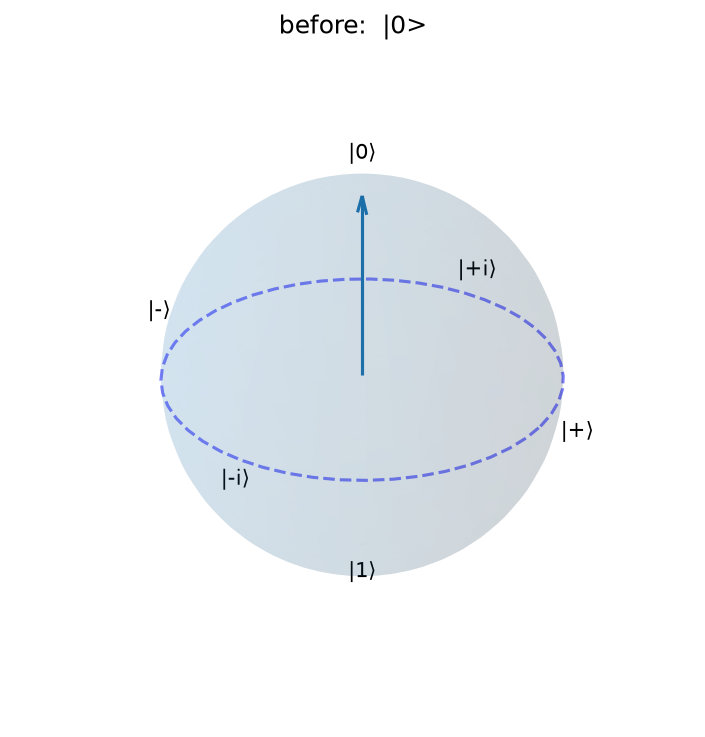

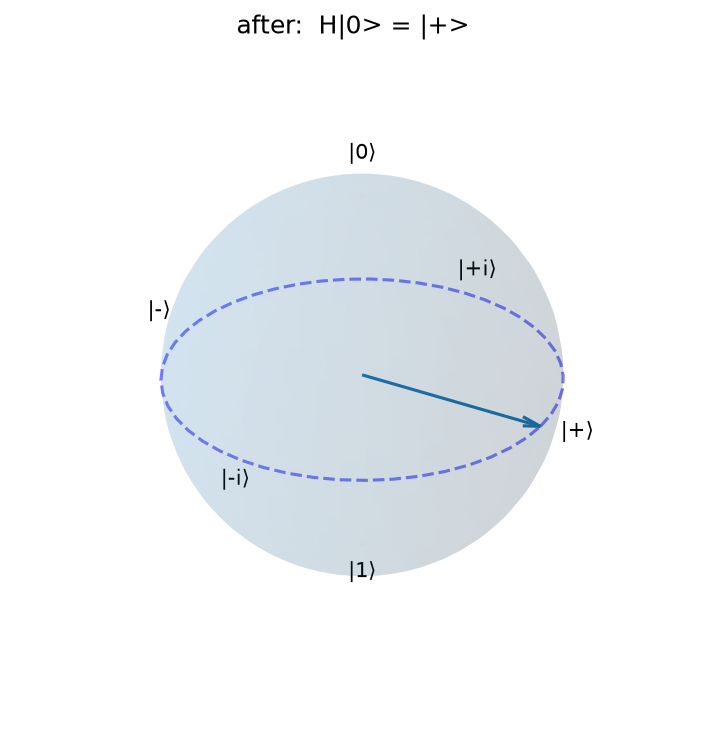

In [6]:
from qilisdk.utils.visualization import QTensorStyle

before = ket(0)                                 # start at the north pole
after = QTensor(H(0).matrix) @ before           # H rotates it down to the equator: |0> -> |+>

before.draw(style=QTensorStyle(title="before:  |0>"))
after.draw(style=QTensorStyle(title="after:  H|0> = |+>"))

Now the two-qubit showcase: the **Bell circuit**, which prepares Part 1's entangled state $|\Phi^+\rangle$. The recipe has two moves: $H$ on qubit 0 creates the superposition, then `CNOT(0, 1)` spreads the correlation to qubit 1:

$$\text{CNOT}\,(H \otimes I)\,|00\rangle \;=\; \tfrac{1}{\sqrt2}\,\bigl(|00\rangle + |11\rangle\bigr).$$

Two notation reminders. $H \otimes I$ means "$H$ on qubit 0 and do-nothing ($I$) on qubit 1": the tensor product from Part 1 is how a 1-qubit gate becomes a 2-qubit operation. And CNOT sits to the *left* of $H \otimes I$ because it happens *second*: function composition, read inside out.

`circuit.draw()` renders the circuit: time flows left to right, and each horizontal wire is one qubit.

Circuit(nqubits=2, gates=[H(0), CNOT(0, 1), M(0, 1)])


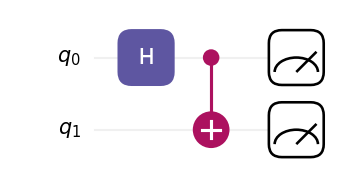

In [7]:
bell = Circuit(2)
bell.add(H(0))            # superposition on qubit 0
bell.add(CNOT(0, 1))      # control = 0, target = 1: entangles them
bell.add(M(0, 1))         # measure qubits 0 and 1
print(bell)
bell.draw()

**Measurement (`M`) is fundamentally different from a gate.** It is *not* unitary: it irreversibly **collapses** the superposition to a single classical bitstring, with probabilities given by the Born rule from Part 1. This is why a circuit that contains `M` has no single unitary matrix, and why an algorithm must arrange its interference *before* the measurement, while the state still holds all $2^n$ amplitudes; once you measure, only the sampled bits remain.

QiliSDK's gate set includes the single-qubit gates `H, X, Y, Z, S, T`, the parameterized rotations `RX, RY, RZ`, the general rotations `U1, U2, U3`, the two-qubit gates `CNOT, CZ, SWAP`, and the combinators `Controlled / Adjoint / Exponential`. One practical gotcha: **rotation angles are keyword-only**. You must write `RX(0, theta=1.57)`; a positional `RX(0, 1.57)` raises a `TypeError`.

A *measurement-free* circuit, by contrast, is one large unitary, and you can ask QiliSDK for its full $2^n \times 2^n$ matrix:

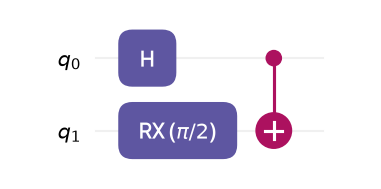

this circuit's unitary has shape: (4, 4)


In [8]:
u = Circuit(2)
u.add(H(0))
u.add(RX(1, theta=np.pi / 2))   # rotation angle is KEYWORD-ONLY
u.add(CNOT(0, 1))
u.draw()                        # picture the circuit whose matrix we're about to build
print("this circuit's unitary has shape:", u.to_matrix().shape)   # (4, 4) = 2**2 x 2**2

## 2.2 · Running a circuit & reading out results

So far we have only *built* circuits. Executing one uses the universal pattern `Backend.execute(functional, readout)`, with three pieces:

1. **Functional**: *what* to run. A bare `Circuit` is not directly executable (QiliSDK raises if you try). You wrap it in **`DigitalPropagation`**, the functional that means "start from $|0\cdots0\rangle$ and propagate the state through this circuit's gates". Think of the functional as the job description and the circuit as one ingredient of it.
2. **Backend**: *where* to run. **`QiliSim`** is the built-in C++ simulator that ships with the pip install. Under the hood it does **state-vector simulation**: it stores all $2^n$ complex amplitudes in memory and applies each gate as a matrix multiply, so it always knows the exact final state. This is Part 1's memory wall in action: every extra qubit doubles the memory, so a laptop tops out in the low 30s of qubits. That wall is exactly why real quantum hardware is interesting.
3. **Readout**: *what* to extract. The fluent `Readout()` builder lets you ask for `with_sampling(...)` (measurement counts, like a real device), `with_expectation(...)` (observable averages, Part 1's $\langle O \rangle$), or `with_state_tomography()` (the exact final state, a simulator privilege we unpack below).

First execution: the one-qubit NOT circuit from 2.1. Quantum outcomes are only random when the measured state is in superposition, and $X|0\rangle = |1\rangle$ is not: it is a basis state. So every one of the 1000 shots must come out `'1'`:

In [9]:
from qilisdk.functionals import DigitalPropagation
from qilisdk.backends import QiliSim
from qilisdk.readout import Readout

result = QiliSim().execute(DigitalPropagation(quantum_not), Readout().with_sampling(nshots=1000))
print(result.get_samples())   # {'1': 1000}: deterministic, like a classical NOT

{'1': 1000}


All 1000 shots agree: `{'1': 1000}`. Quantum circuits are only random where you *put* randomness. Now something with real randomness: sample the Bell circuit. **Sampling** mimics a real device: it draws `nshots` measurement outcomes from the Born-rule distribution, so the counts are *empirical* and fluctuate from run to run. That statistical wobble is called **shot noise**, and it shrinks like $1/\sqrt{\text{nshots}}$: one more decimal digit of precision costs 100x more shots.

In [10]:
bell_result = QiliSim().execute(DigitalPropagation(bell), Readout().with_sampling(nshots=1000))
print("samples      :", bell_result.get_samples())          # only '00' and '11', roughly 500 each
print("probabilities:", bell_result.get_probabilities())    # the same counts, as empirical frequencies

samples      : {'00': 511, '11': 489}
probabilities: {'00': 0.511, '11': 0.489}


Only `00` and `11` appear: the two qubits always agree, but *which* value they agree on is a fair coin flip. This is what entanglement looks like when you measure it.

**How to read the bitstrings:** QiliSDK's sample keys are **big-endian**: the *first* character is qubit 0. This is easy to verify: a circuit that applies $X$ only to qubit 0 of a two-qubit register samples `'10'`, never `'01'`. Keep the convention in mind whenever you convert bitstrings to integers, as we will for the dice roller.

Because we are on a **simulator**, we also have an option no real device has: we can read the **exact** probabilities straight from the stored state vector, with zero shot noise. The readout is called `with_state_tomography()`. The name comes from hardware practice, where **tomography** means reconstructing the full quantum state from many repeated measurements in different bases ("tomo" is Greek for slice, as in a CT scan). On hardware that reconstruction is expensive; on a simulator the state is already sitting in memory, so QiliSDK reuses the name for this free, exact readout.

Rule of thumb for the rest of the tutorial: use the **exact** path when you need reproducible numbers on screen, and **sampling** when you want to mimic what real hardware would return.

In [11]:
exact = QiliSim().execute(DigitalPropagation(bell), Readout().with_state_tomography())
exact_probs = exact.state_tomography.probabilities
# round() hides ordinary floating-point noise (the raw values print as 0.4999999999999999)
print({k: round(p, 6) for k, p in exact_probs.items()})   # {'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}

{'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}


A histogram makes the sampled-vs-exact contrast visible. The bars show what we actually sampled; the dashed lines mark the exact expectation, $\text{nshots} \times p$, for each outcome. The bar-vs-line gap *is* shot noise:

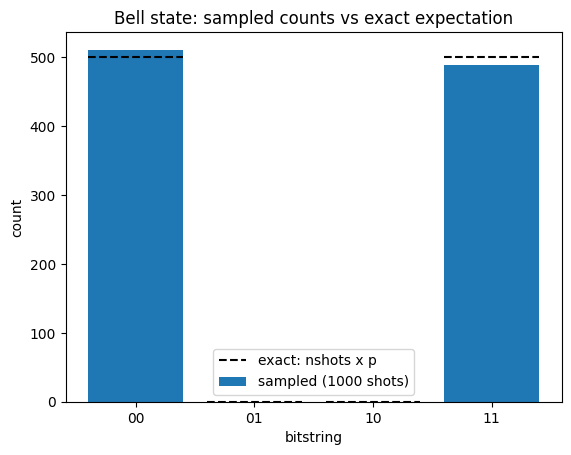

In [12]:
counts = bell_result.get_samples()
labels = sorted(exact_probs)                  # all four outcomes, including the never-seen ones
positions = range(len(labels))

plt.bar(positions, [counts.get(k, 0) for k in labels], tick_label=labels, label="sampled (1000 shots)")
for i, k in enumerate(labels):
    expected = 1000 * exact_probs[k]
    plt.hlines(expected, i - 0.4, i + 0.4, colors="black", linestyles="dashed",
               label="exact: nshots x p" if i == 0 else None)
plt.title("Bell state: sampled counts vs exact expectation")
plt.xlabel("bitstring")
plt.ylabel("count")
plt.legend()
plt.show()

## 2.3 · Entanglement on a circuit

We built the Bell circuit, ran it, and saw the two qubits always agree. Now let us follow its state gate by gate to see *why*:

1. **Start:** $|00\rangle$. Both qubits are definitely 0.
2. **After $H$ on qubit 0:** $\tfrac{1}{\sqrt2}\,(|00\rangle + |10\rangle)$. Qubit 0 is now undecided, but qubit 1 is still definitely 0 in both branches. No entanglement yet: this is a product state.
3. **After `CNOT(0, 1)`:** $\tfrac{1}{\sqrt2}\,(|00\rangle + |11\rangle)$. Inside the branch where qubit 0 is 1, the CNOT flipped qubit 1. The gate did not decide the coin flip; it *copied the correlation*, tying the two qubits' outcomes together.

In short: $H$ creates the randomness, and CNOT distributes it. The pattern scales, too: each additional CNOT attaches one more qubit to the same coin flip, giving a ladder of qubits that all agree. This is the pattern the next exercise builds on.

### 🧩 Exercise 2.1: a shared secret for three parties

**The outcome you are engineering:** three parties (Alice, Bob, Charlie) each hold one qubit of a 3-qubit register. When they all measure, each receives the *same* random bit. Nobody chose the bit, it did not exist before the measurements, and an outsider cannot predict it. This correlation is the primitive behind **quantum secret sharing** and entanglement-based **key distribution**. Recall Part 1's collapse rule: measurement hands each party exactly one classical bit; the circuit's job is to choreograph the state so those three bits always agree.

Build the circuit and **prove** the correlation two ways:

1. Build a 3-qubit circuit in which all three qubits always agree on one random bit, then measure all three. Hint: the Bell recipe extends naturally, one source of randomness plus a ladder of CNOTs passing it along. Derive the gates from the step-through above rather than looking them up.
2. Sample 1000 shots and print the counts: only two bitstrings should ever appear, each around 500.
3. Prove it exactly: print the state-tomography probabilities (rounded). They should put exactly $0.5$ on each of the two all-agree outcomes and $0$ everywhere else.
4. Bar-plot the sampled counts.

This is the state Part 1 called GHZ, except now you have *built* it from gates instead of calling a factory function.

samples: {'000': 506, '111': 494}
exact  : {'000': 0.5, '001': 0.0, '010': 0.0, '011': 0.0, '100': 0.0, '101': 0.0, '110': 0.0, '111': 0.5}


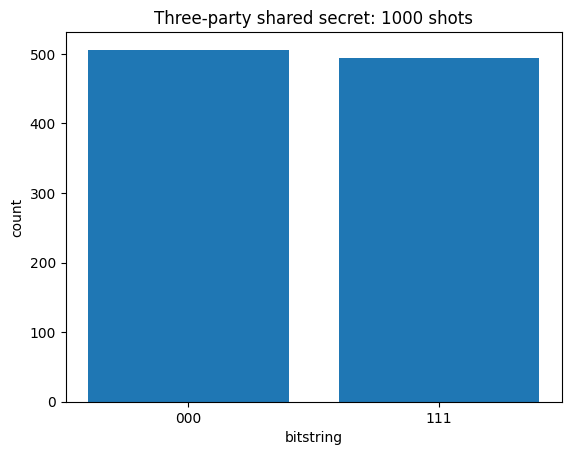

In [13]:
secret = Circuit(3)

# step 1: one coin flip, then a ladder of CNOTs passing it down the register
secret.add(H(0))
secret.add(CNOT(0, 1))
secret.add(CNOT(1, 2))
secret.add(M(0, 1, 2))

# step 2: sampled proof, only '000' and '111' ever appear
secret_result = QiliSim().execute(DigitalPropagation(secret), Readout().with_sampling(nshots=1000))
secret_counts = secret_result.get_samples()
print("samples:", secret_counts)

# step 3: exact proof: probability 0.5 on each all-agree outcome, 0 everywhere else
secret_exact = QiliSim().execute(DigitalPropagation(secret), Readout().with_state_tomography())
print("exact  :", {k: round(p, 6) for k, p in secret_exact.state_tomography.probabilities.items()})

# step 4: histogram of the sampled counts
secret_labels = sorted(secret_counts)
plt.bar(secret_labels, [secret_counts[k] for k in secret_labels])
plt.title("Three-party shared secret: 1000 shots")
plt.xlabel("bitstring")
plt.ylabel("count")
plt.show()

## 2.4 · A quantum dice roller

This section builds a small but genuinely useful program. Random numbers underpin cryptography, lotteries, scientific simulation, and online gaming, and classical "randomness" shares one weakness: it is pseudo-random, produced by an algorithm that only *looks* unpredictable. Recover the seed and every draw can be replayed. Quantum measurement is different: the randomness of the Born rule is not a modeling convenience but, as far as physics can tell, fundamental. That is why companies such as ID Quantique sell quantum random number generators (QRNGs), and why the ANU QRNG streams quantum random bits over the web.

We build one here as a **provably fair d20** (a 20-sided die):

1. Put $n = 5$ qubits each through an $H$: the register becomes a uniform superposition over all $2^5 = 32$ bitstrings.
2. **Prove fairness first.** The exact readout shows every one of the 32 outcomes at exactly $1/32 = 0.03125$, *before* we trust a single shot. No classical die or software RNG can give you that guarantee in advance.
3. **Roll.** Each shot yields 5 random bits; `int(bits, 2) + 1` maps them to a value from 1 to 32.
4. **Reject values above 20** and reroll them. This is **rejection sampling**, the same technique Python's `random.randrange` uses internally to avoid modulo bias. We expect to keep $20/32 = 62.5\%$ of the raw shots.

Structurally this is a commercial QRNG at toy scale: a uniform quantum source followed by classical post-processing.

One caveat: QiliSim is a simulator, so the randomness here is still pseudo-random underneath. The point is that this same circuit, unchanged, runs on real hardware (Part 6, `SpeQtrum`), where the physical guarantee becomes real.

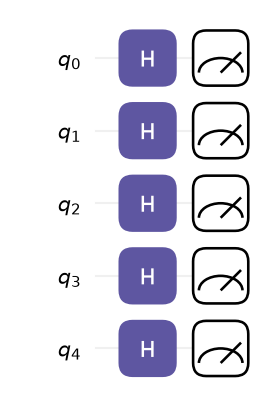

outcomes: 32 | min p: 0.03125 | max p: 0.03125
kept 2438 of 4000 raw samples (61%, expected 20/32 = 62.5%)
a few rolls: {1: 105, 2: 104, 3: 130, 4: 116, 5: 108} ...


In [14]:
from collections import Counter

n = 5                                        # 5 qubits -> 32 raw outcomes
d20 = Circuit(n)
d20.add([H(q) for q in range(n)])            # .add also accepts a list of gates
d20.add(M(*range(n)))
d20.draw()                                   # 5 Hadamards in parallel = a uniform 5-bit source

# fairness proof: every outcome at exactly 1/32
d20_exact = QiliSim().execute(DigitalPropagation(d20), Readout().with_state_tomography())
d20_probs = d20_exact.state_tomography.probabilities
print("outcomes:", len(d20_probs),
      "| min p:", round(min(d20_probs.values()), 6),
      "| max p:", round(max(d20_probs.values()), 6))

# roll it: sample, then reject values above 20
d20_result = QiliSim().execute(DigitalPropagation(d20), Readout().with_sampling(nshots=4000))
rolls = Counter()
kept = 0
for bitstring, count in d20_result.get_samples().items():
    value = int(bitstring, 2) + 1            # 5 bits -> a value in 1..32
    if value <= 20:                          # rejection sampling, like real QRNGs do
        rolls[value] += count
        kept += count
print(f"kept {kept} of 4000 raw samples ({kept / 4000:.0%}, expected 20/32 = 62.5%)")
print("a few rolls:", dict(sorted(rolls.items())[:5]), "...")

### 🧩 Exercise 2.2: build a quantum d6

Now build the classic six-sided die, this time with fairness you can verify in advance. The exercise walks the full pipeline (build, wrap, execute, read out) plus one design decision that is yours to make.

1. Decide how many qubits a d6 needs: the smallest $n$ with $2^n \geq 6$.
2. Put every qubit in uniform superposition and measure them all.
3. Prove fairness with the exact readout: every raw outcome should sit at exactly $1/2^n$.
4. Sample 4000 shots, convert each bitstring to a face value with `int(bitstring, 2) + 1`, and keep only values up to 6 (rejection sampling).
5. Report the keep rate (expected $6/8 = 75\%$) and print the counts per face.

Hints: the d20 demo above is your template, but do not copy it blindly; the design decision changes more than one line. Remember that `.add` accepts a list of gates and that `M(*range(n))` measures the whole register.

In [15]:
from collections import Counter

# step 1 + 2: 3 qubits give 2**3 = 8 raw outcomes, the smallest power of two >= 6
n = 3
d6 = Circuit(n)
d6.add([H(q) for q in range(n)])
d6.add(M(*range(n)))

# step 3: fairness proof, every raw outcome at exactly 1/8 = 0.125
d6_exact = QiliSim().execute(DigitalPropagation(d6), Readout().with_state_tomography())
d6_probs = d6_exact.state_tomography.probabilities
print("outcomes:", len(d6_probs),
      "| min p:", round(min(d6_probs.values()), 6),
      "| max p:", round(max(d6_probs.values()), 6))

# step 4: roll it with rejection sampling
d6_result = QiliSim().execute(DigitalPropagation(d6), Readout().with_sampling(nshots=4000))
rolls = Counter()
kept = 0
for bitstring, count in d6_result.get_samples().items():
    value = int(bitstring, 2) + 1
    if value <= 6:
        rolls[value] += count
        kept += count

# step 5: keep rate and per-face counts
print(f"kept {kept} of 4000 raw samples ({kept / 4000:.0%}, expected 6/8 = 75%)")
print("rolls per face:", dict(sorted(rolls.items())))

outcomes: 8 | min p: 0.125 | max p: 0.125
kept 3061 of 4000 raw samples (77%, expected 6/8 = 75%)
rolls per face: {1: 542, 2: 466, 3: 533, 4: 483, 5: 569, 6: 468}


## Recap & what's next

- **Gates are unitary matrices.** A `Circuit` composes them with `.add(...)`, and applying $A$ then $B$ computes $B\,A\,|\psi\rangle$, in function-composition order. **Measurement** (`M`) is the one non-unitary step: it collapses the state into classical bits.
- Each single-qubit gate is a **rotation of the Bloch sphere**: $X$ is the **bit flip** ($|0\rangle\leftrightarrow|1\rangle$), $Z$ the **phase flip** ($|+\rangle\leftrightarrow|-\rangle$), and $H$ the bridge between the two bases. Any gate's matrix is available on **`.matrix`**.
- The universal execution call is **`Backend.execute(functional, readout)`**: wrap a circuit in `DigitalPropagation`, run it on `QiliSim`, read it out with the `Readout` builder.
- **Sampling** gives empirical counts with shot noise (shrinking like $1/\sqrt{\text{nshots}}$); **state tomography** gives exact probabilities, which only a simulator can provide. Use exact readout for reproducible numbers and sampling to mimic hardware.
- You entangled three qubits into a shared random bit that no outsider can predict, then built a **provably fair quantum dice roller**, structurally a commercial QRNG at toy scale.

**Next, Part 3, Hamiltonians & Analog Quantum Computing:** we compute the *other* way. Instead of discrete gates, we evolve a physical system continuously in time under a Hamiltonian, and use that to solve a real problem: scheduling four conference talks around their conflicts by quantum annealing.